In [1]:
import os
import sys

project_root = "/root/work/tvm-ansor"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build-release"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build-release")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build-release:" + os.environ.get("LD_LIBRARY_PATH", "")


import tvm

TARGET = tvm.target.Target("cuda")


In [ ]:
import numpy as np


from tvm import auto_scheduler
from util_modules.task_paths import load_and_register_tasks
import numpy as np
import importlib
# importlib.reload(sys.modules["util_modules.plot.latent_cost_geometry"])

tasks = load_and_register_tasks()


In [7]:
json_files

['/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/1179_([6d628209072e3e3dd8f49359935acea6,[1,28,28,448],[1,1,448,128],[1,1,1,128],[1,28,28,128]],cuda).json',
 '/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/575_([97d6699a083ccfb8655170ee1eb94e98,[8,128,128],[8,128,64],[8,128,64]],cuda).json',
 '/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/208_([c4a40b16179bb6885ba76d9e196a3add,[1,14,14,184],[3,3,184,1],[1,1,1,184],[1,14,14,184]],cuda).json',
 '/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/110_([3c9fbd9e221b7e0bfc63dfd45b25fc77,[1,64,512],[1,64,1],[1,64,1]],cuda).json',
 '/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/145_([80312e579af64168aa60737451fa5268,[1,256,1024],[1,256,1]],cuda).json',
 '/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/1194_([e9b946222771d439a3d55a341ca06155,[1,16,256,256],[1,16,256,256]],cuda).json',
 '/root/work/t

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/1179_([6d628209072e3e3dd8f49359935acea6,[1,28,28,448],[1,1,448,128],[1,1,1,128],[1,28,28,128]],cuda).json


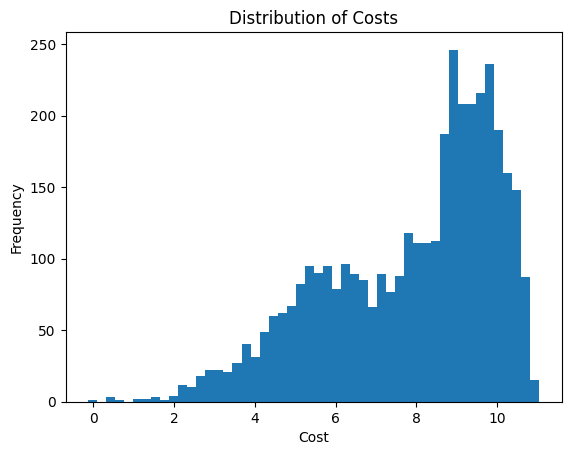

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/575_([97d6699a083ccfb8655170ee1eb94e98,[8,128,128],[8,128,64],[8,128,64]],cuda).json


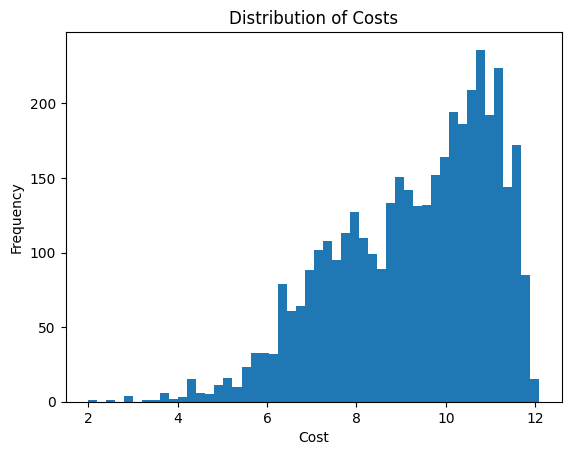

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/208_([c4a40b16179bb6885ba76d9e196a3add,[1,14,14,184],[3,3,184,1],[1,1,1,184],[1,14,14,184]],cuda).json


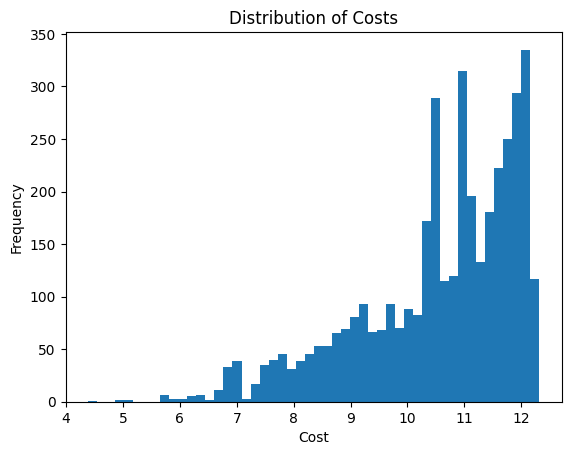

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/110_([3c9fbd9e221b7e0bfc63dfd45b25fc77,[1,64,512],[1,64,1],[1,64,1]],cuda).json
Error occurred while processing /root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/110_([3c9fbd9e221b7e0bfc63dfd45b25fc77,[1,64,512],[1,64,1],[1,64,1]],cuda).json: 
/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/145_([80312e579af64168aa60737451fa5268,[1,256,1024],[1,256,1]],cuda).json
Error occurred while processing /root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/145_([80312e579af64168aa60737451fa5268,[1,256,1024],[1,256,1]],cuda).json: 
/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/1194_([e9b946222771d439a3d55a341ca06155,[1,16,256,256],[1,16,256,256]],cuda).json
Error occurred while processing /root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/1194_([e9b946222771d439a3d55a341ca06155,[1,16,256,256],[1,16,256,256]],cuda).j

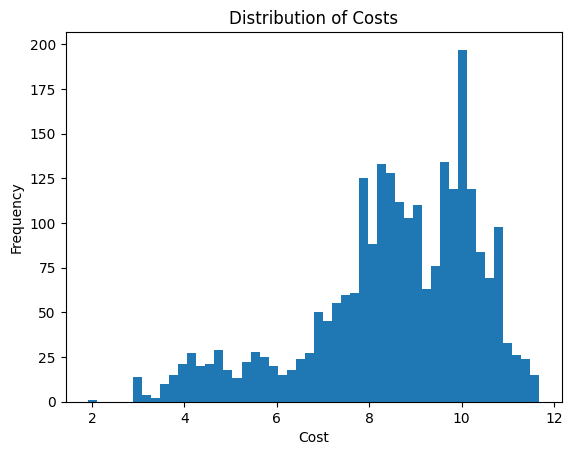

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/169_([08f7449d79e570b7274174709e5e5e01,[1,512],[400,512],[1,400],[1,400]],cuda).json
Error occurred while processing /root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/169_([08f7449d79e570b7274174709e5e5e01,[1,512],[400,512],[1,400],[1,400]],cuda).json: 
/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/317_([88a2e34d300a6ccfcf0228f0b90f13ec,[1,112,112,64],[3,3,64,1],[1,1,1,64],[1,56,56,64]],cuda).json


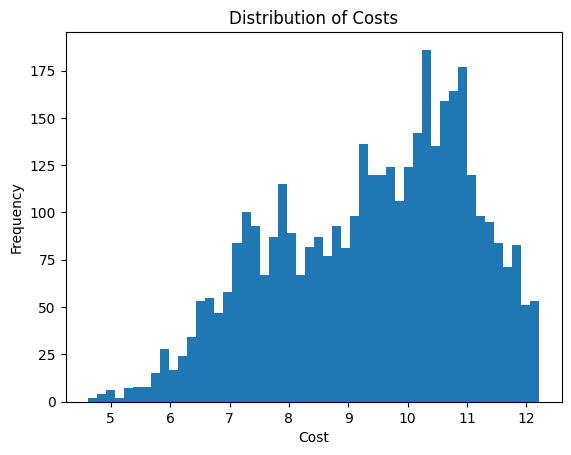

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/302_([72858abe65e3185202b62d45a3956c75,[1,8,8,128],[6,6,32,128],[1,8,8,32]],cuda).json


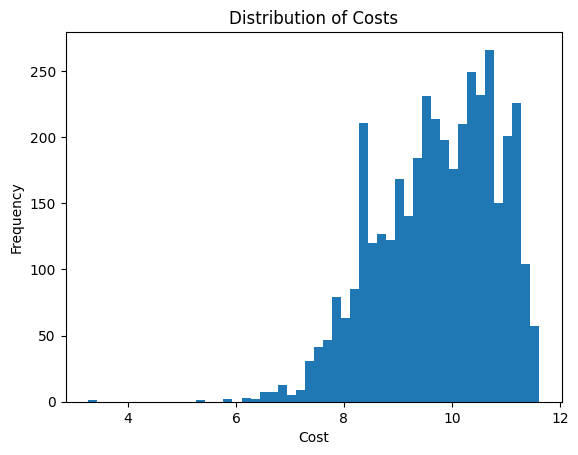

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/648_([fa181f391f61b842bf273ba527e4a060,[1,224,224,3],[3,3,3,32],[1,1,1,32],[1,112,112,32]],cuda).json


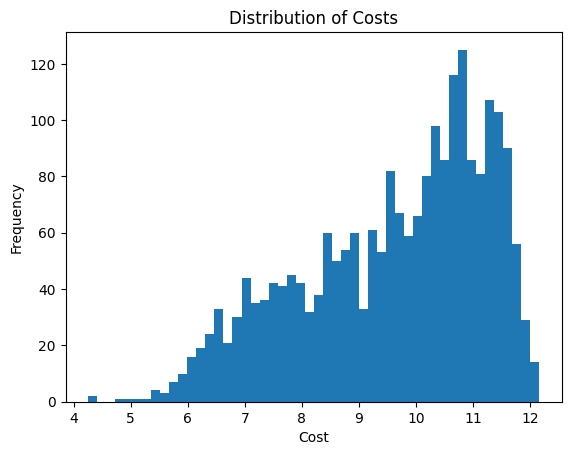

/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/249_([c219de5fa5fe694343f2826ebe8e47ce,[1,112,112,64],[1,56,56,64]],cuda).json


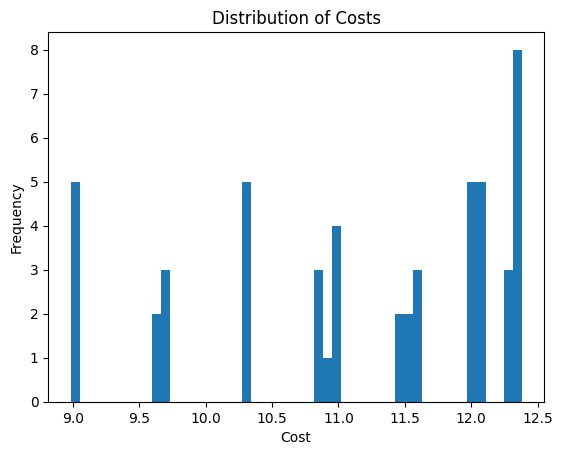

In [13]:
from util_modules.input.integrated import json_to_VecCosts
from util_modules.plot.cost_dist import plot_cost_distribution
importlib.reload(sys.modules["util_modules.input.integrated"])

# json_file = "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json"
json_file = "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/1490_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json"
from glob import glob
json_files = glob("/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/*.json")

for json_file in json_files:
    print(f"{json_file}")

    try:
        raw_sch, costs = json_to_VecCosts(json_file, type="schedules", return_raw_cost=False)
    except Exception as e:
        print(f"Error occurred while processing {json_file}: {e}")
        continue
    # raw_features, costs = json_to_VecCosts(json_file, type="features")
    # features = raw_features.sum(axis=1)
    # raw_extents, costs = json_to_VecCosts(json_file, type="extents")


    

    plot_cost_distribution(costs)

    # sorted(costs)